<a href="https://colab.research.google.com/github/Ivaanloopez09/Procesos-Estocasticos/blob/main/GPs_PRADO_Ivan_L%C3%B3pez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar GPs

El objetivo es aprender a simular trayectorias de un GP, usando algunas de las herramientas más habituales de machine learning (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos las imágenes vistas en las diapositivas.

In [2]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se obtienen 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utilizamos la función `np.random.multivariate_normal`.

Además, visualizamos el resultado obtenido, así como su shape.

In [3]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.identity(3)
num_samples = 50
samples = np.random.multivariate_normal(mean = vector_medias, cov = matriz_covarianzas, size = num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-0.09268556 -1.58127321 -0.04496818]
 [-0.16138794  0.76300208 -2.18875355]
 [-0.79015918  0.12976946  0.08522421]
 [ 1.13421892  1.81249893  0.36784373]
 [-0.22935829 -0.69826851  1.17259416]
 [-0.28617866 -0.35385787 -0.21441082]
 [ 0.01842399  0.40955406 -1.03990538]
 [-1.85122885  1.30019761 -1.17254095]
 [-0.33458555 -1.80310116  0.48117516]
 [ 1.42767881 -0.43609248  1.84860345]
 [-0.39204532 -1.34285021 -0.17789453]
 [-0.75043765 -0.17682552 -0.07036698]
 [ 0.88924071 -1.2204261   0.36037016]
 [-0.28309013  1.18409508 -0.75652248]
 [-0.08359609  0.33684983 -1.38925201]
 [-0.63763203 -1.4649088   0.96233758]
 [ 1.77448236  0.99721766 -0.35468049]
 [-0.54608784 -1.02186914 -0.25804251]
 [-0.44237966  0.01131172 -0.72301986]
 [ 1.3286994   0.59282863 -1.02583391]
 [ 0.06193348 -1.30972675 -1.71452996]
 [-1.5923167   0.98457755 -0.85155199]
 [-0.14938772  0.22523601 -0.82361686]
 [ 0.31101085  0.22355897  1.27727387]
 [ 0.39687559  0.11522708  0.86485657

Hacemos ahora lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Puedes simplificar algo el código si usas la función `np.diag` para crear la matriz diagonal.

¿Qué diferencias esperarías ver en las muestras obtenidas?


In [4]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.diag([1,10,100])
num_samples = 50
samples = np.random.multivariate_normal(mean = vector_medias, cov = matriz_covarianzas, size = num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 1.27261431e+00 -2.98221193e+00 -2.86425398e+00]
 [ 2.02089700e-01 -1.19850210e+00 -1.62830807e+01]
 [ 1.50525219e+00  1.07285084e+00 -1.93987322e+00]
 [ 1.36135882e+00 -2.72697655e+00 -9.41744677e-01]
 [-6.04864590e-01  1.68697709e+00  7.96381079e+00]
 [ 1.15453699e-02  9.07424080e+00  1.38026500e+01]
 [ 4.58496130e-01 -4.28594429e+00  7.49901661e+00]
 [ 4.64224900e-01 -2.44606414e+00 -8.81947650e+00]
 [ 1.13055369e-01 -1.36108074e-01 -5.84291310e+00]
 [ 1.07570541e+00  5.82401251e+00 -5.94218239e+00]
 [-2.10695734e+00 -6.16332367e+00  7.62222008e+00]
 [-1.86395000e+00  4.36263406e+00 -4.16287428e+00]
 [-3.46945814e-01  8.77542530e-02 -8.67597874e+00]
 [-1.76412378e+00 -1.26171509e+00  8.46108739e+00]
 [ 1.74621029e-01  1.07507432e+00 -9.09251727e+00]
 [-8.29388445e-01  3.30787007e+00  1.81817271e+00]
 [-4.58255273e-01  3.25277046e+00  5.27840966e+00]
 [-2.18929653e-01  2.89875330e+00  5.68066537e+00]
 [-7.93794700e-01 -3.26072674e+00 -1.53943401e+01]
 [ 1

Como esperábamos, ahora nos sale una mayor dispersión de los datos según miramos más a la derecha en las columnas.

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permitirá simular un GP con kernel RBF. Y a continuación la usaremos para generar imágenes similares a las de las diapositivas de los apuntes. Usaremos función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función). Todo ello necesita del concepto de _clases_, algo que (creo) no se estudia en el grado en matemáticas.

Definimos la función principal:

In [5]:
def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  """
  Simular un GP con kernel RBF.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  num_samples: número de muestras a generar. Int.

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).

  """

  # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar
  # np.zeros_like

  vector_medias = np.zeros_like(t)

  # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la
  # vectorización de numpy y en particular la idea de broadcasting que se
  # comentó en la intro a numpy.

  n = len(t)
  t = np.asarray(t) #Necesiramos que t sea un array para poder hacerle reshape
  tf=t.reshape(1,n)
  tc=t.reshape(n,1)
  matriz_distancias = tf-tc

  matriz_covs = sigma_sq * np.exp(-(matriz_distancias**2) / (2 * lengthscale**2))

  # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista
  # antes: np.random.multivariate_normal
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, size=num_samples)

  return samples

Ahora utilizamos esta función para generar imágenes similares a las de las diapositivas 59 y 62 de los apuntes.

Para ello, generamos las trayectorias con la función recién definida, `simular_GP_RBF`, y las píntamos con `plt.subplots`.

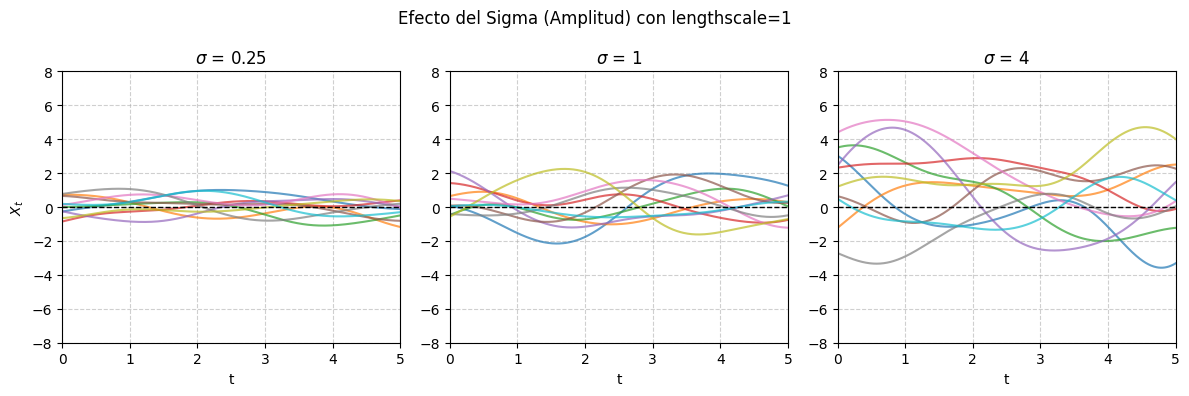

In [6]:
# DIAPOSITIVA 59

# eje x
t = np.linspace(0, 5, 500)

# valores de sigma
sigmas=[0.25,1,4]

# figura
fig, axs = plt.subplots(ncols=3, figsize= (12,4))

for i, sigma in enumerate(sigmas):
    y = simular_GP_RBF(t, sigma_sq=sigma, lengthscale=1, num_samples=10)
    axs[i].plot(t, y.T, alpha=0.7)
    axs[i].axhline(0, color='black', linestyle='--', linewidth=1)
    axs[i].set_title(rf'$\sigma$ = {sigma}')
    axs[i].set_xlabel('t')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].set_xlim(0,5)
    axs[i].set_ylim(-8,8)

axs[0].set_ylabel(r'$X_t$')
fig.suptitle('Efecto del Sigma (Amplitud) con lengthscale=1')
plt.tight_layout()
plt.show()

In [ ]:
# DIAPOSITIVA 62

# eje x
t = np.linspace(0, 5, 500)

# valores de sigma
lengthscales=[0.25,1,4]

# figura
fig, axs = plt.subplots(ncols=3, figsize= (12,4))

for i, l in enumerate(lengthscales):
    y = simular_GP_RBF(t, sigma_sq=1, lengthscale=l, num_samples=10)
    axs[i].plot(t, y.T, alpha=0.7)
    axs[i].axhline(0, color='black', linestyle='--', linewidth=1)
    axs[i].set_title('lengthscale = ' f'{l}')
    axs[i].set_xlabel('t')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].set_xlim(0,5)
    axs[i].set_ylim(-3,3)

axs[0].set_ylabel(r'$X_t$')
fig.suptitle('Efecto del Lengthscale con ' r'$\sigma = 0.25$')
plt.tight_layout()
plt.show()

## 3. Simular un GP con kernel periódico

En esta sección vamos a definir una función `simular_GP_periodic` que nos permita simular un GP con kernel periódico. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [16]:
def simular_GP_periodic(t, sigma_sq=1, lengthscale=1, period=1, num_samples=1):
  """
  Simular un GP con kernel periodico.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  period: período del kernel. Float.
  num_samples: número de muestras a generar. Int.

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).

  """

  # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar
  # np.zeros_like

  vector_medias = np.zeros_like(t)

  # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la
  # vectorización de numpy y en particular la idea de broadcasting que se
  # comentó en la intro a numpy.

  n = len(t)
  t = np.asarray(t) #Necesiramos que t sea un array para poder hacerle reshape
  tf=t.reshape(1,n)
  tc=t.reshape(n,1)
  matriz_distancias = tf-tc

  matriz_covs = sigma_sq * np.exp((-2/lengthscale**2)*(np.sin((np.pi*matriz_distancias)/period))**2)

  # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista
  # antes: np.random.multivariate_normal
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, size=num_samples)

  return samples

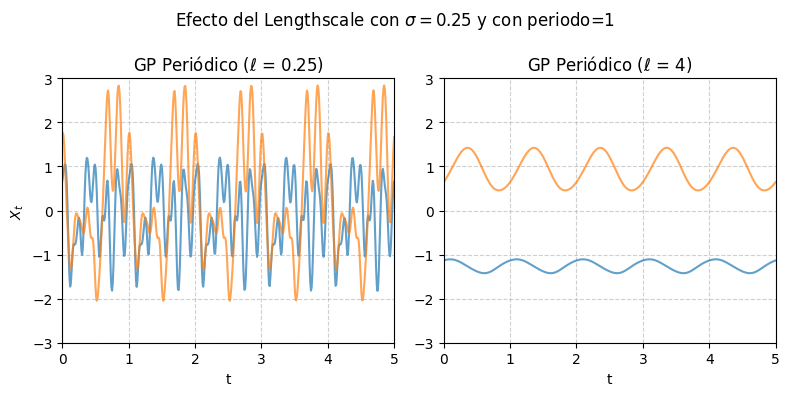

In [25]:
# DIAPOSITIVA 72

# eje x
t = np.linspace(0, 5, 500)

# valores del lengthscale
lengthscales=[0.25,4]

# figura
fig, axs = plt.subplots(ncols=2, figsize= (8,4))

for i, l in enumerate(lengthscales):
    y = simular_GP_periodic(t, sigma_sq=1, lengthscale=l, period=1, num_samples=2)
    axs[i].plot(t, y.T, alpha=0.7)
    axs[i].set_title(r'GP Periódico ($\ell$ = ' f'{l})')
    axs[i].set_xlabel('t')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].set_xlim(0,5)
    axs[i].set_ylim(-3,3)

axs[0].set_ylabel(r'$X_t$')
fig.suptitle('Efecto del Lengthscale con ' r'$\sigma = 1$ y con periodo=1')
plt.tight_layout()
plt.show()

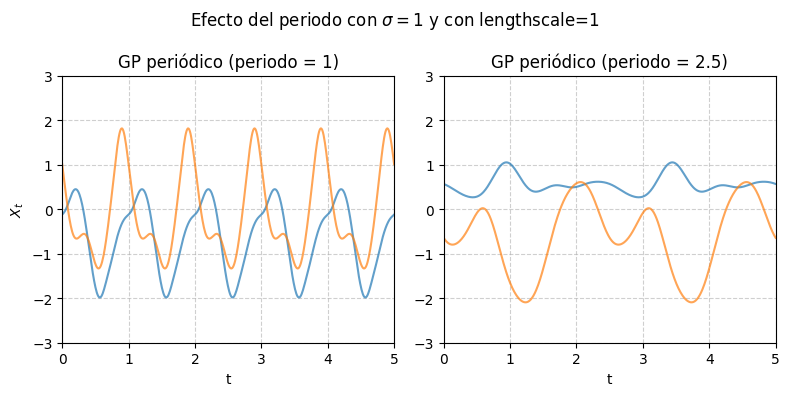

In [26]:
# DIAPOSITIVA 74

# eje x
t = np.linspace(0, 5, 500)

# valores del periodo
periodos=[1,2.5]

# figura
fig, axs = plt.subplots(ncols=2, figsize= (8,4))

for i, p in enumerate(periodos):
    y = simular_GP_periodic(t, sigma_sq=1, lengthscale=1, period=p, num_samples=2)
    axs[i].plot(t, y.T, alpha=0.7)
    axs[i].set_title(r'GP periódico (periodo = ' f'{p})')
    axs[i].set_xlabel('t')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].set_xlim(0,5)
    axs[i].set_ylim(-3,3)

axs[0].set_ylabel(r'$X_t$')
fig.suptitle('Efecto del periodo con ' r'$\sigma = 1$ y con lengthscale=1')
plt.tight_layout()
plt.show()

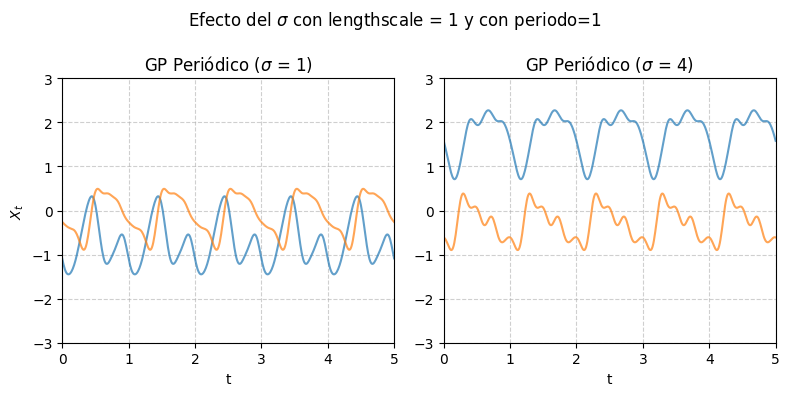

In [29]:
# DIAPOSITIVA 76

# eje x
t = np.linspace(0, 5, 500)

# valores de sigma
sigmas=[1,4]

# figura
fig, axs = plt.subplots(ncols=2, figsize= (8,4))

for i, sigma in enumerate(sigmas):
    y = simular_GP_periodic(t, sigma_sq=sigma, lengthscale=1, period=1, num_samples=2)
    axs[i].plot(t, y.T, alpha=0.7)
    axs[i].set_title(r'GP Periódico ($\sigma$ = ' f'{sigma})')
    axs[i].set_xlabel('t')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].set_xlim(0,5)
    axs[i].set_ylim(-3,3)

axs[0].set_ylabel(r'$X_t$')
fig.suptitle(r'Efecto del $\sigma$ con lengthscale = 1 y con periodo=1')
plt.tight_layout()
plt.show()

## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [36]:
def simular_GP_DPKpoly(t, m=3, num_samples=1):
    """
    Simular un GP con kernel DPK polinómico.

    Kernel:
        k(s,t) = sum_{j=0}^m s^j t^j

    Funciones base:
        1, t, t^2, ..., t^m
    """

    t = np.asarray(t, dtype=float)

    # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar
    # np.zeros_like
    vector_medias = np.zeros_like(t)

    # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la
    # vectorización de numpy y en particular la idea de broadcasting que se
    # comentó en la intro a numpy.

    # Matriz previa
    # Tiene shape (n, m+1)
    # columna 0: t^0 = 1
    # columna 1: t^1
    # ...
    # columna m: t^m
    M = np.column_stack([t**j for j in range(m+1)])

    # Matriz de covarianzas
    matriz_covs = M @ M.T

    # Simulaciones
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, size=num_samples)

    # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista
    # antes: np.random.multivariate_normal
    return samples

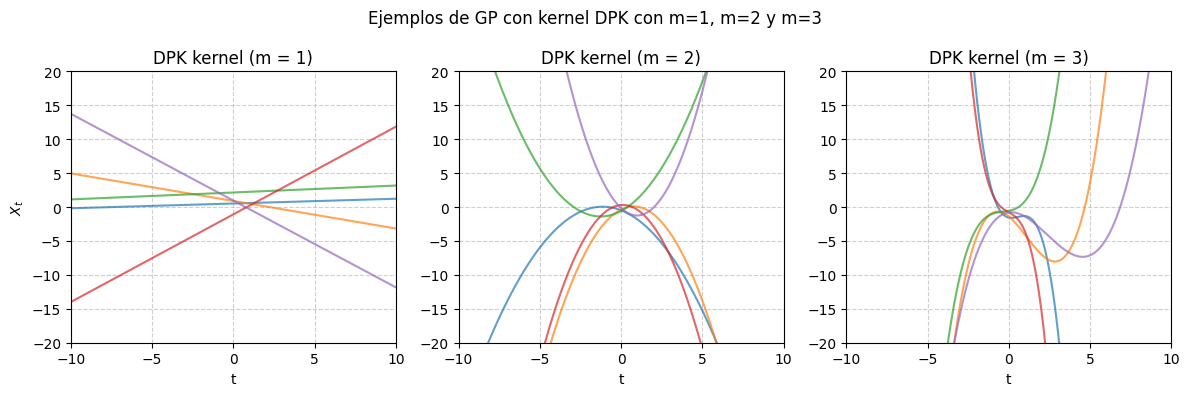

In [39]:
# DIAPOSITIVA 89

# eje x
t = np.linspace(-10, 10, 500)

# figura
fig, axs = plt.subplots(ncols=3, figsize= (12,4))

for i, m in enumerate([1, 2, 3]):
    y = simular_GP_DPKpoly(t, m, num_samples=5)
    axs[i].plot(t, y.T, alpha=0.7)
    axs[i].set_title(r'DPK kernel (m = ' f'{m})')
    axs[i].set_xlabel('t')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].set_xlim(-10,10)
    axs[i].set_ylim(-20,20)

axs[0].set_ylabel(r'$X_t$')
fig.suptitle(r'Ejemplos de GP con kernel DPK con m=1, m=2 y m=3')
plt.tight_layout()
plt.show()

## 5. Opcional: ¿Cómo hacer que el kernel se pase como parámetro? ¿y la función de medias?

Estas preguntas, bastante generales, se pueden abordar de muchas maneras. En esta sección se presenta muy brevemente una solución basada en el paradigma de programación orientada a objetos (POO). Es la manera más habitual de programar en Python y en muchos otros lenguajes.

La idea de la POO es estructurar el código usando el concepto de _clase_. Una _clase_ es algo ``parecido'' a un _struct_, que probablemente se viese en las asignaturas de C++, aunque una clase tiene mayor funcionalidad. Concretamente, una _clase_ es una estructura que nos permite crear objetos que contienen dos cosas principalmente:
* Atributos: valores que forman parte del objeto.
* Métodos: acciones que puede realizar el objeto.

A continuación definimos una _clase_ para describir el kernel RBF. La clase define dos atributos:
* ```self.sigma_sq```: es el parámetro $\sigma^2$.
* ```self.lengthscale```: es el parámetro $\ell$.
Y la clase define un método (además del ```__init__``` básico, que se usa para crear un objeto de la clase):
* ```__call__(self, t, s)```: permite evaluar el kernel usando como inputs los arrays t y s. Es decir, calcula la matriz $(k(t_i, s_j))_{ij}$.

In [ ]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

En la celda anterior simplemente hemos definido "qué es un objeto de tipo RBF".

En la celda siguiente, utilizamos la clase recién definida para crear un objeto concreto de ese tipo:

In [ ]:
my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))  # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)   # Aquí estamos usando el método __call__ (es un método especial que se utiliza de esta manera)
print(cov_mat.shape)  # Aquí deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100)

<class '__main__.RBF'>
(100, 100)


A continuación definimos una clase para la función de medias constantemente igual a cero:

In [ ]:
class Zero_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

Y creamos un objeto de ese tipo:

In [ ]:
my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

<class '__main__.Zero_Mean_Function'>
(100,)
True


Definimos ahora una función ```simular_GP``` que recibe como parámetros __cualquier función de medias__ (```mf```) y __cualquier kernel__ (```kernel```). Lo único que necesitamos es que sean objetos de clases en las que se haya definido el método ```__call__``` igual que se ha hecho arriba.

In [ ]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

Para validar esta función, vamos a generar la imagen de la diapositiva 64, donde se usaba la función de medias identidad y el kernel RBF.

Para ello, definimos una clase para la función de medias identidad:

In [ ]:
class Identity_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Finalmente, usamos esta clase, la clase RBF, y la función ```simular_GP``` para obtener lo buscado:

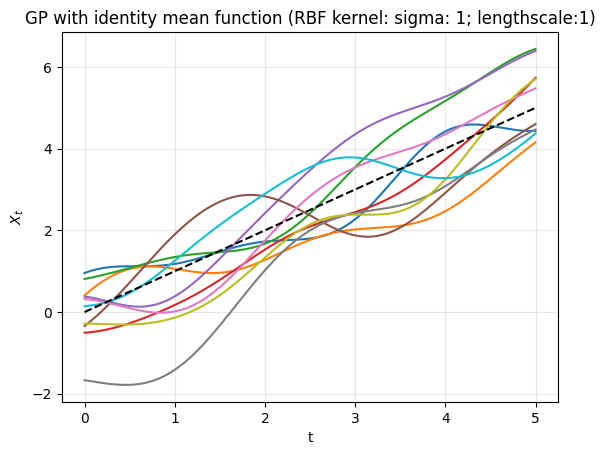

In [ ]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP with identity mean function (RBF kernel: sigma: {sigma}; lengthscale:{lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()
